In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lattice_k_sym import SpinConfiguration
from cpu_fast_lattice_clusters_k_mp import SpinConfiguration as SCclust

In [2]:
lamb = np.linspace(0., 1., 21)
lamb

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [ ]:
nxs = [4, 6]
ny = 4
gaps = np.zeros((4, len(lamb)))

for ii, nx in enumerate(nxs):
    mag = int(nx*ny/2)
    print(mag)
    print(nx, ny)
    for il, lam in enumerate(lamb):
        print(f'Calculating lambda = {lam}')
        sc = SpinConfiguration(N_x = nx, N_y = ny, lamb=lam, magnon_number=mag)
        min_e_0 = sc.get_ground_state()[0]
        sc = SpinConfiguration(N_x = nx, N_y = ny, lamb=lam, magnon_number=mag - 1)
        eign_en = sc.get_ground_state()[0]

        gaps[ii, il] = eign_en-min_e_0

clusters = ['18A', '24C']

for ii, key in enumerate(clusters):
    mag = int(int(key[:2])/2)
    print(mag)
    print(key)
    for il, lam in enumerate(lamb):
        print(f'Calculating lambda = {lam}')
        sc = SCclust(key=key, lamb=lam, magnon_number=mag)
        min_e_0 = sc.get_ground_state()[0]
        sc = SCclust(key=key, lamb=lam, magnon_number=mag - 1)
        eign_en = sc.get_ground_state()[0]

        gaps[ii + 2, il] = eign_en-min_e_0

#np.savetxt('data/other/E_gap_gamma_var_lambda.txt', gaps)

8
4 4
Calculating lambda = 0.0
Calculating lambda = 0.05
Calculating lambda = 0.1
Calculating lambda = 0.15000000000000002
Calculating lambda = 0.2


Exception ignored in: <function _get_module_lock.<locals>.cb at 0x1064ad6c0>
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 451, in cb
KeyboardInterrupt: Process SpawnProcess-97:

Process SpawnProcess-96:
Process SpawnProcess-99:
Process SpawnProcess-92:
Process SpawnProcess-95:
Process SpawnProcess-94:
Process SpawnProcess-91:
Process SpawnProcess-93:
Process SpawnProcess-100:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/concurrent/futures/process.py", line 242, in _process_worker
    call_item = call_queue.get(block=True)
  Fi

KeyboardInterrupt: 

In [4]:
m_ss = np.zeros(len(lamb))

on_a_cluster = True

if on_a_cluster:
    key = '18A'
    mag = int(int(key[:2])/2)
    print(mag)
    print(key)
    for il, lam in enumerate(lamb):
        print(f'Calculating lambda = {lam}')
        sc = SCclust(key=key, lamb=lam, magnon_number=mag)
        gs_state = sc.get_ground_state()[1]

        rotation_map = sc.rotation_map
        c_map = sc.cluster.cluster_map
        m_s = 0
        
        for repr, ii in sc.representatives.items():
            config = sc.map_int_to_config(repr)
            rot = config * rotation_map + (1 - config) * (1 - rotation_map)
            rot *= c_map

            m_s += np.square(np.abs(gs_state[ii])) * (np.sum(rot)/int(key[:2]))
        
        m_ss[il] = m_s
else:
    nx,ny = 4,4
    mag = int(nx*ny/2)
    print(mag)
    print(nx, ny)
    sc = SpinConfiguration(N_x = nx, N_y = ny, lamb=1., magnon_number=mag)
    for il, lam in enumerate(lamb):
        print(f'Calculating lambda = {lam}')
        sc.generate_hamiltonian(lamb = lam)
        sc.get_eigva_eigve()
        gs_state = sc.get_ground_state()[1]

        rotation_map = sc.rotation_map
        m_s = 0
        
        for repr, ii in sc.representatives.items():
            config = sc.map_int_to_config(repr)
            rot = config * rotation_map + (1 - config) * (1 - rotation_map)
            m_s += np.square(np.abs(gs_state[ii])) * (np.mean(rot))
        
        print(m_s)
        
        m_ss[il] = m_s

9
18A
Calculating lambda = 0.0
Calculating lambda = 0.05
Calculating lambda = 0.1
Calculating lambda = 0.15000000000000002
Calculating lambda = 0.2
Calculating lambda = 0.25
Calculating lambda = 0.30000000000000004
Calculating lambda = 0.35000000000000003
Calculating lambda = 0.4
Calculating lambda = 0.45
Calculating lambda = 0.5
Calculating lambda = 0.55
Calculating lambda = 0.6000000000000001
Calculating lambda = 0.65
Calculating lambda = 0.7000000000000001
Calculating lambda = 0.75
Calculating lambda = 0.8
Calculating lambda = 0.8500000000000001
Calculating lambda = 0.9
Calculating lambda = 0.9500000000000001
Calculating lambda = 1.0


[0.05367345 0.05531585 0.057072   0.05895686 0.06098853 0.0631888
 0.06558465 0.06821021 0.07110829 0.07433499 0.07796429 0.08209722
 0.08687604 0.09250826 0.09931414 0.10781942 0.11896967 0.13471005
 0.16002902 0.21498001 0.49999832]
1.3791026179461656


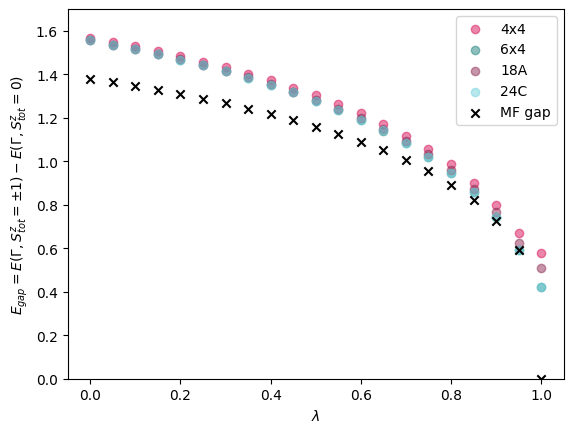

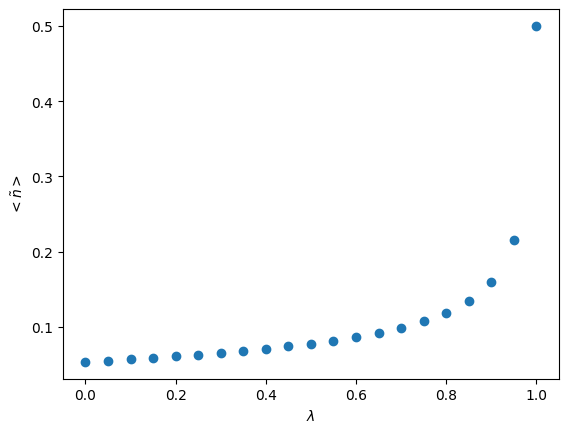

In [5]:
gaps = np.loadtxt('data/other/E_gap_gamma_var_lambda.txt')

colors = [
    '#d81159', '#218380', '#8f2d56', '#73d2de'
]
labels = ['4x4', '6x4', '18A', '24C']

for ii in range(gaps.shape[0]):
    plt.scatter(lamb, gaps[ii, :], c = colors[ii], label = labels[ii], alpha = .5)

print(m_ss)

lambda_range = np.linspace(0, 1., 101)
y = 2*np.sqrt((1. + (1. - lamb) * m_ss * 4)**2 - 1)
print(y[0])
plt.scatter(lamb, y, c = 'black', marker = 'x', label = 'MF gap')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$E_{gap} = E(\Gamma, S^z_{tot} = \pm 1) - E(\Gamma, S^z_{tot} = 0)$')
plt.ylim([0, 1.7])
plt.legend()
plt.show()

plt.scatter(lamb, m_ss)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$<\tilde n>$')
plt.show()

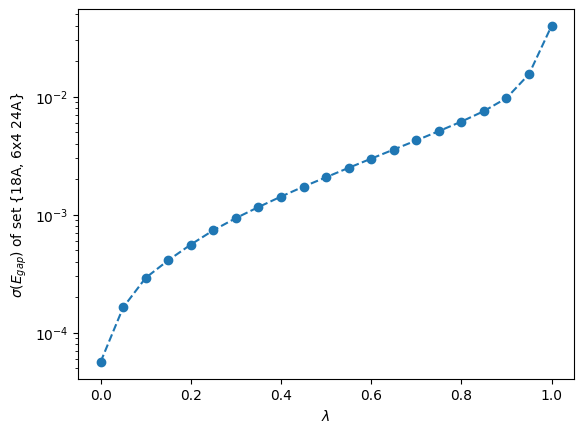

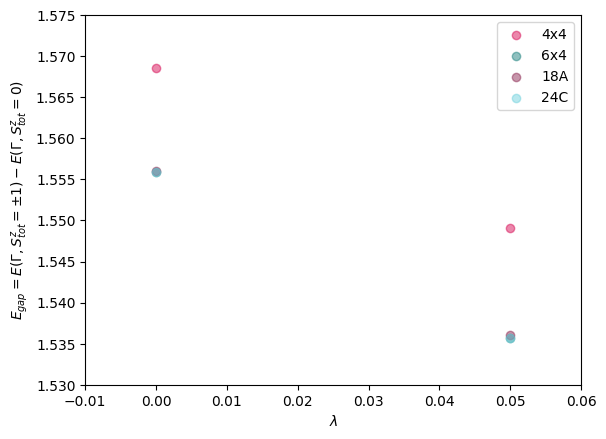

In [6]:
stdev = np.sqrt(np.var(gaps[1:, :], axis = 0))
plt.semilogy(lamb, stdev, 'o--')

if np.min(stdev) < 3e-6:
    xs = [0., 1.]
    ys = [3e-6, 3e-6]
    plt.semilogy(xs, ys, c = 'gray', ls = '--', label = 'numerical accuracy')
    plt.legend()

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\sigma(E_{gap})$ of set {18A, 6x4 24A}')
plt.show()

for ii in range(gaps.shape[0]):
    plt.scatter(lamb, gaps[ii, :], c = colors[ii], label = labels[ii], alpha = .5)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$E_{gap} = E(\Gamma, S^z_{tot} = \pm 1) - E(\Gamma, S^z_{tot} = 0)$')
plt.xlim([-.01, .06])
plt.ylim([1.53, 1.575])
plt.legend()
plt.show()

In [ ]:
nx, ny = 4, 4
n = nx * ny
steps = 5000

sc = SpinConfiguration(nx, ny, int(n/2), lowest_eignstates=1, delta=1., lamb=1., print_data=False)
ens = []

from tqdm import tqdm

for ii in tqdm(range(steps)):
    sc.generate_hamiltonian()
    sc.get_eigva_eigve()
    min_e = sc.get_ground_state()[0]
    ens.append(min_e)

print('λ = 1')
print(f'Mean energy: {np.mean(ens)}')
print(f'Standard deviation: {np.sqrt(np.var(ens))}')

sc = SpinConfiguration(nx, ny, int(n/2), lowest_eignstates=1, delta=1., lamb=0., print_data=False)
ens = []

from tqdm import tqdm

for ii in tqdm(range(steps)):
    sc.generate_hamiltonian()
    sc.get_eigva_eigve()
    min_e = sc.get_ground_state()[0]
    ens.append(min_e)

print('λ = 0')
print(f'Mean energy: {np.mean(ens)}')
print(f'Standard deviation: {np.sqrt(np.var(ens))}')


100%|██████████| 5000/5000 [03:54<00:00, 21.29it/s]


λ = 1
Mean energy: -11.228483178901673
Standard deviation: 2.7422916426943946e-06


100%|██████████| 5000/5000 [05:28<00:00, 15.24it/s]

λ = 0
Mean energy: -9.905236911964417
Standard deviation: 2.9936746642403386e-06


In [ ]:
nx, ny = 4, 4
n = nx * ny
steps = 500

sc = SpinConfiguration(nx, ny, int(n/2), lowest_eignstates=1, delta=1., lamb=0., print_data=False)
ens = []

from tqdm import tqdm

for ii in tqdm(range(steps)):
    sc.generate_hamiltonian()
    sc.get_eigva_eigve()
    min_e = sc.get_ground_state()[0]
    ens.append(min_e)

print('λ = 0')
print(f'Mean energy: {np.mean(ens)}')
print(f'Standard deviation: {np.sqrt(np.var(ens))}')


100%|██████████| 500/500 [00:32<00:00, 15.41it/s]

λ = 0
Mean energy: -9.905236597061156
Standard deviation: 3.3778250373889357e-06


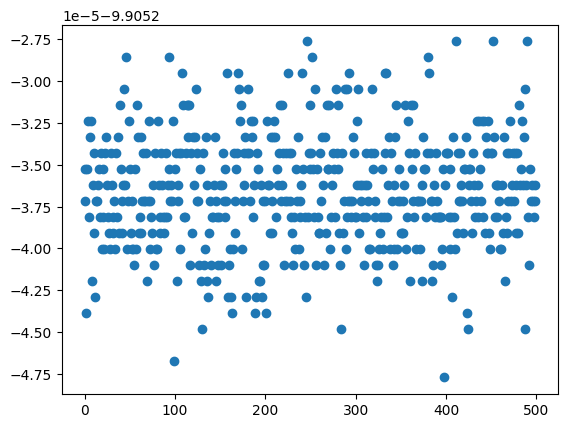

In [ ]:
plt.scatter(range(steps), ens)

In [8]:
key = '18A'
mag = int(int(key[:2])/2)
print(mag)
print(key)
deltas = [1., 2., 1.35, 1.74]
for il, delta in enumerate(deltas):
    print(f'Calculating delta = {delta}')
    sc = SCclust(key=key, delta=delta, lamb=0., magnon_number=mag)
    gs_state = sc.get_ground_state()[1]

    rotation_map = sc.rotation_map
    c_map = sc.cluster.cluster_map
    m_s = 0
    
    for repr, ii in sc.representatives.items():
        config = sc.map_int_to_config(repr)
        rot = config * rotation_map + (1 - config) * (1 - rotation_map)
        rot *= c_map

        m_s += np.square(np.abs(gs_state[ii])) * (np.sum(rot)/int(key[:2]))
    
    print(m_s)


9
18A
Calculating delta = 1.0
0.053673480448829004
Calculating delta = 2.0
0.01483042339122892
Calculating delta = 1.35
0.031014567441533143
Calculating delta = 1.74
0.01931482058867302
